# Hybrid TPU + GDDR6-AiM Evaluation

This notebook evaluates an LLM workload on a hybrid architecture that combines a
TPU-style systolic array with a GDDR6-AiM (Accelerator-in-Memory) processing-in-memory
system. A `Fork` in the architecture lets the mapper assign each einsum to whichever
compute path is more efficient:

- **TPU path**: 128x128 systolic array with 128 MB global buffer (compute-bound ops)
- **AiM path**: 512 independent PUs with 32 GB/s per-bank DRAM (memory-bound ops)

## Setup

In [6]:
from pathlib import Path
import accelforge as af

models_dir = Path("../models")

HYBRID_ARCH = models_dir / "tpu_aim_hybrid.yaml"
WORKLOAD = models_dir / "gpt3_6.7B_kv_cache.yaml"

BATCH_SIZE = 1
N_TOKENS = 8096
N_NEW_TOKENS = 8096

spec = af.Spec.from_yaml(
    HYBRID_ARCH,
    WORKLOAD,
    jinja_parse_data={"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS, "N_NEW_TOKENS": N_NEW_TOKENS},
)

## Architecture

The hybrid architecture uses a `Fork` to split into two compute paths from shared
HBM main memory. The TPU path has a deep memory hierarchy (GlobalBuffer, LocalBuffer,
Register) feeding a 128x128 systolic array. The AiM path has 512 independent
processing units, each with its own 32 GB/s DRAM bank and 2 KB global buffer.

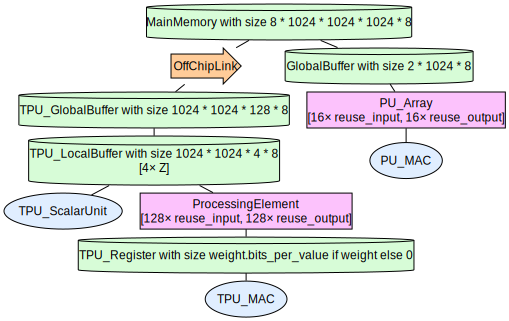

In [84]:
spec.arch

## Workload

GPT-3-like transformer with small ranks for fast mapper evaluation. Includes QKV
projections, attention (QK, softmax, AV), output projection, and FFN layers.
Rank ratios match GPT-3 6.7B scaled down by 64x.

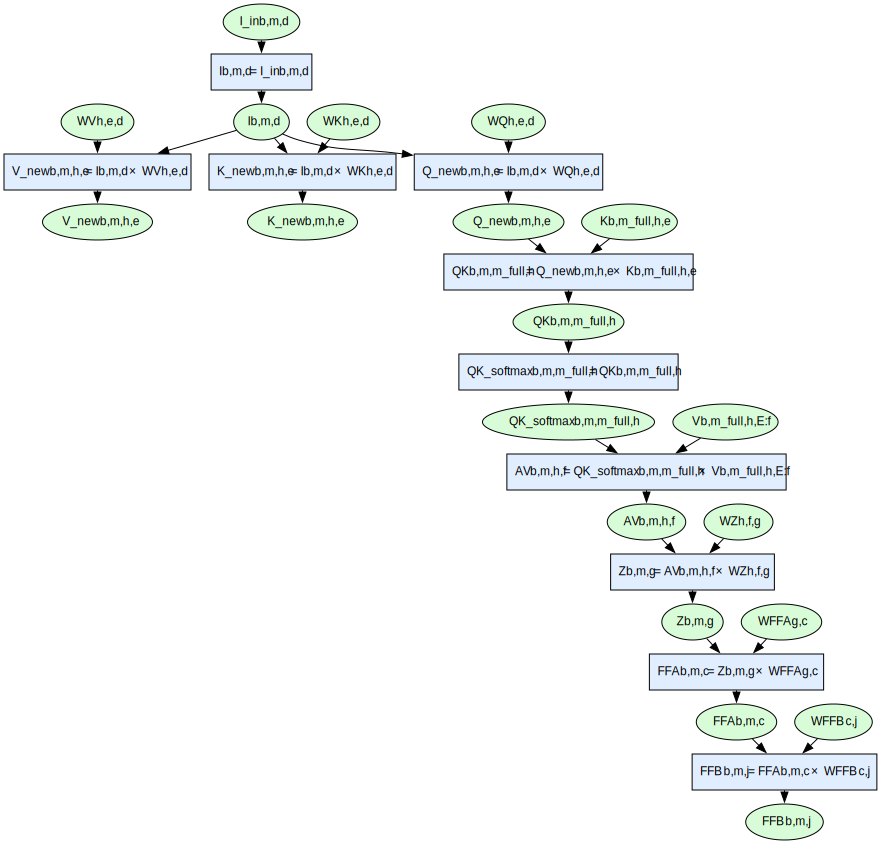

In [85]:
spec.workload

## Map Workload to Architecture

We map the full workload in a single call. The mapper jointly optimizes across all
einsums and automatically assigns each to the TPU or AiM path through the Fork.

In [ ]:
spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
mapping = spec.map_workload_to_arch()
# mapping[0].render()

Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 10/10 [00:03<00:00,  2.60it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum I: 2it [00:00, 147.15it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum V_new: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_MAC Einsum I: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum K_new: 0it [00:00, ?it/s]
Generating pmapping templates for compute PU_MAC Einsum I: 2it [00:00, 290.40it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum QK: 0it [00:00, ?it/s], ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Q_new: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Z: 0it [00:00, ?it/s]s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum AV: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum FFA: 0it [00:00, 

Einsum I has 4 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I_in in OffChipLink] [I in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  [I in OffChipLink] [I_in in OffChipLink] S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	2	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	3	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
Einsum V_new has 81 pmapping jobs:
	0	[WV in MainMemory] [V_new in MainMemory] T-b  T-d  T-m  [V_new in OffChipLink] [WV in OffChipLink] [I in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I in TPU_LocalBuffer] T-e  T-h  [V_new in TPU_LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in TPU_Register] T-b  T-m  TPU_MAC computes V_new
	1	[WV in MainMemory]

Generating pmappings:   1%|▏         | 13/976 [00:15<13:36,  1.18it/s]

KeyboardInterrupt: 

EDP IDX: 1


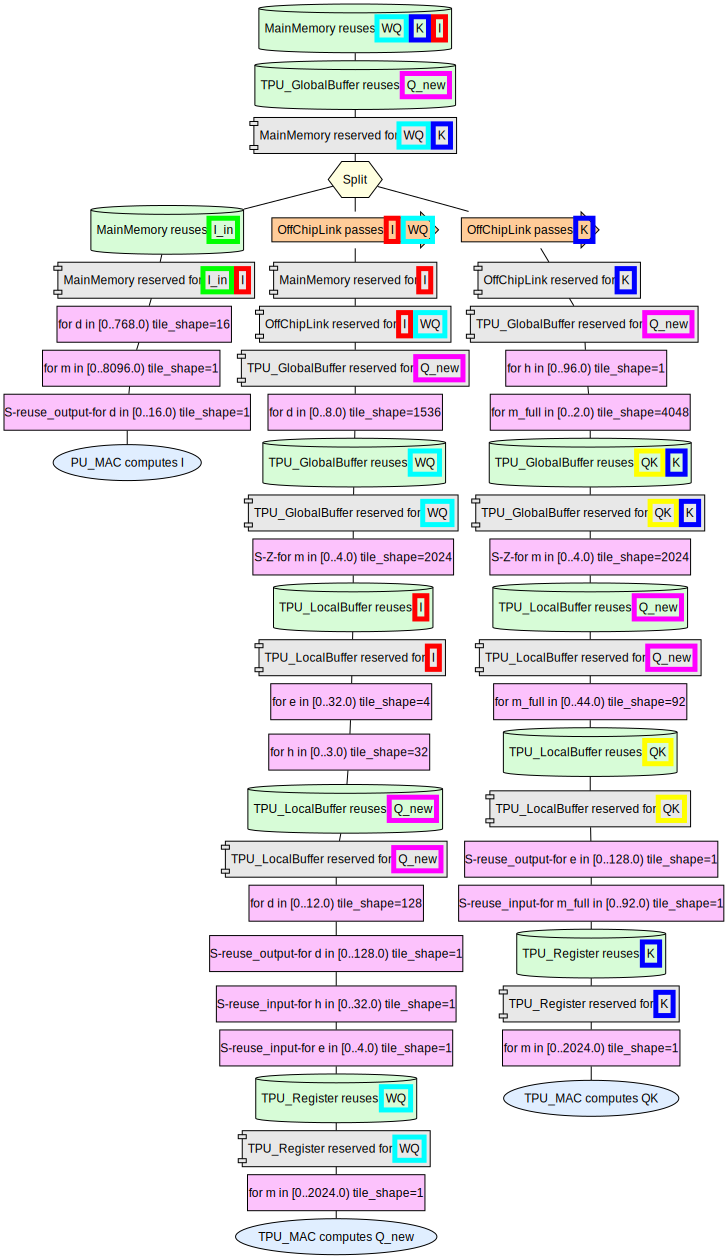

0.4823174316307133
0.03443807


In [22]:
def pick(val, idx=None):
    """If val is a list (Pareto set), pick element at idx (default: 0)."""
    if isinstance(val, list):
        return val[idx if idx is not None else 0]
    return val


def best_energy_latency_product_idx(result):
    """Choose Pareto index minimizing energy * latency"""
    energies = result.energy()
    latencies = result.latency()
    if not isinstance(energies, list):
        return 0
    idx = min(range(len(energies)), key=lambda i: energies[i] * latencies[i])
    print("EDP IDX:", idx)
    return idx
    # return None

IDX = best_energy_latency_product_idx(mapping)

tmapping = mapping[IDX]
display(tmapping.render())

# energy_by_comp = tmapping.energy(per_component=True)
# latency_by_comp = tmapping.latency(per_component=True)

# print(energy_by_comp)
# print(latency_by_comp)
print(tmapping.energy())
print(tmapping.latency())



### Per-Einsum Breakdown

Shows energy and latency for each operation, and which compute path was used.

In [16]:

tmapping_energy = tmapping.energy(per_einsum=True)
tmapping_latency = tmapping.latency(per_einsum=True)

# Determine which path each einsum uses by checking the mapping string
mapping_col = "Total<SEP>mapping"
has_mapping_col = mapping_col in mapping.data.columns


def detect_path(einsum_name, row_index: int):
    """Detect TPU vs AiM from the mapping string for a given einsum."""
    if has_mapping_col:
        row = mapping.data.iloc[min(row_index, len(mapping.data) - 1)]
        mapping_str = str(row.get(mapping_col, ""))
        ein_col = f"{einsum_name}<SEP>mapping"
        if ein_col in mapping.data.columns:
            mapping_str = str(row.get(ein_col, ""))
        if "TPU_MAC" in mapping_str or "TPU_ScalarUnit" in mapping_str:
            return "TPU"
        if "PU_MAC" in mapping_str:
            return "AiM"
    return "?"


print(f"{'Einsum':<15} {'Path':<6} {'Energy (J)':>14} {'Latency (s)':>14}")
print("-" * 55)


tpu_einsums, aim_einsums = [], []

for ein in tmapping_energy:
    e = pick(tmapping_energy[ein], IDX)
    l = pick(tmapping_latency.get(ein, 0), IDX)
    path = detect_path(ein, IDX)
    if path == "TPU":
        tpu_einsums.append(ein)
    elif path == "AiM":
        aim_einsums.append(ein)
print(f"\nTPU einsums: {', '.join(tpu_einsums) or 'none'}")
print(f"AiM einsums: {', '.join(aim_einsums) or 'none'}")

Einsum          Path       Energy (J)    Latency (s)
-------------------------------------------------------

TPU einsums: Q_new, QK
AiM einsums: I


## Visualizations

Energy breakdown by component, stacked by einsum.

(<Figure size 300x400 with 1 Axes>,
 [<Axes: title={'center': '0-m0'}, ylabel='Energy (J)'>])

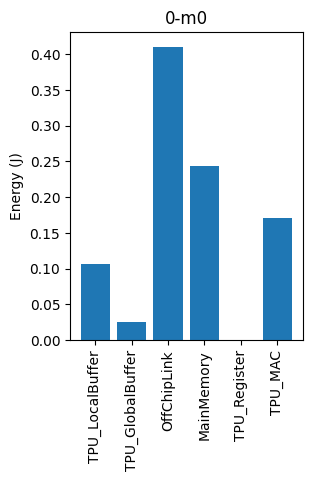

In [17]:
from accelforge.plotting.mappings import plot_energy_breakdown

plot_energy_breakdown([tmapping], separate_by=["component"])

(<Figure size 300x400 with 1 Axes>,
 [<Axes: title={'center': '0-m0'}, ylabel='Latency (s)'>])

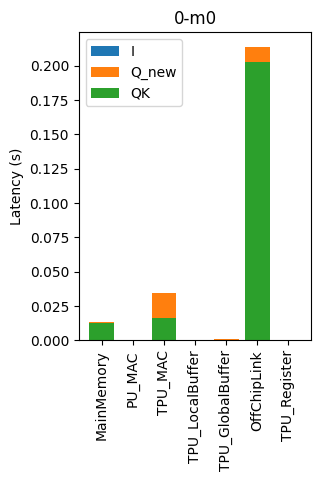

In [18]:
from accelforge.plotting.mappings import plot_latency_breakdown

plot_latency_breakdown([tmapping], separate_by=["component"], stack_by=["einsum"])

(<Figure size 300x400 with 1 Axes>,
 [<Axes: title={'center': '0-m0'}, ylabel='Energy (J)'>])

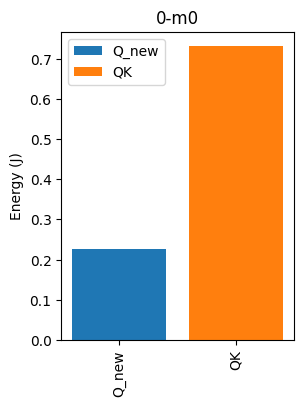

In [19]:
plot_energy_breakdown([tmapping], separate_by=["einsum"], stack_by=["einsum"])

## Decode vs Prefill Comparison

During decode (M=1), operations are memory-bound and should favor AiM.
During prefill (M=128), operations become compute-bound and should favor the TPU.
We compare the two phases by re-mapping with different token counts.

## Per-Einsum: TPU vs AiM  Comparison

To understand why the mapper picks one path over the other, we map each einsum
independently to a TPU-only architecture and an AiM-only architecture (both sharing
the same MainMemory). This lets us directly compare energy and latency per-einsum
on each path.

In [96]:
params = {"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS}
einsum_names = [e.name for e in spec.workload.einsums]
arch_paths = [("TPU", models_dir / "tpu_only.yaml"), ("AiM", models_dir / "aim_only.yaml")]

comparison = {}

for name in einsum_names:
    row = {}
    for label, arch_path in arch_paths:
        try:
            s = af.Spec.from_yaml(arch_path, WORKLOAD, jinja_parse_data=params)
            s.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
            r = s.map_workload_to_arch(einsum_names=[name], print_progress=False)
            # Pick min-latency Pareto point
            lat = r.latency()
            if isinstance(lat, list):
                idx = min(range(len(lat)), key=lambda i: lat[i])
                row[label] = {"energy": lat[idx], "latency": lat[idx]}
                # Fix: get energy at same index
                eng = r.energy()
                row[label] = {"energy": eng[idx], "latency": lat[idx]}
            else:
                row[label] = {"energy": r.energy(), "latency": r.latency()}
        except Exception as e:
            row[label] = {"energy": float("nan"), "latency": float("nan"), "error": str(e)}
    comparison[name] = row
    
    tpu_lat = row["TPU"]["latency"]
    aim_lat = row["AiM"]["latency"]
    winner = "TPU" if tpu_lat <= aim_lat else "AiM"
    print(f"{name:<15} TPU lat={tpu_lat:.3e}  AiM lat={aim_lat:.3e}  -> {winner}")

I               TPU lat=3.840e-07  AiM lat=4.800e-08  -> AiM
V_new           TPU lat=4.719e-03  AiM lat=3.134e-04  -> AiM
K_new           TPU lat=4.719e-03  AiM lat=3.134e-04  -> AiM
Q_new           TPU lat=4.719e-03  AiM lat=3.134e-04  -> AiM
QK              TPU lat=3.134e-03  AiM lat=2.080e-04  -> AiM
QK_softmax      TPU lat=4.858e-05  AiM lat=3.036e-06  -> AiM
AV              TPU lat=3.134e-03  AiM lat=2.065e-04  -> AiM
Z               TPU lat=4.719e-03  AiM lat=3.134e-04  -> AiM
FFA             TPU lat=1.888e-02  AiM lat=1.253e-03  -> AiM
FFB             TPU lat=1.888e-02  AiM lat=1.253e-03  -> AiM


### Summary Table

In [97]:
import math

header = f"{'Einsum':<15} {'TPU Energy':>12} {'TPU Latency':>12} {'AiM Energy':>12} {'AiM Latency':>12} {'Lat Winner':>10} {'Lat Ratio':>10}"
print(header)
print("-" * len(header))

for name, row in comparison.items():
    te = row["TPU"]["energy"]
    tl = row["TPU"]["latency"]
    ae = row["AiM"]["energy"]
    al = row["AiM"]["latency"]
    
    if math.isnan(tl) or math.isnan(al):
        winner = "error"
        ratio = "N/A"
    elif tl <= al:
        winner = "TPU"
        ratio = f"{al/tl:.2f}x"
    else:
        winner = "AiM"
        ratio = f"{tl/al:.2f}x"
    
    print(f"{name:<15} {te:>12.3e} {tl:>12.3e} {ae:>12.3e} {al:>12.3e} {winner:>10} {ratio:>10}")

Einsum            TPU Energy  TPU Latency   AiM Energy  AiM Latency Lat Winner  Lat Ratio
-----------------------------------------------------------------------------------------
I                  1.168e-06    3.840e-07    1.666e-14    4.800e-08        AiM      8.00x
V_new              1.556e-02    4.719e-03    6.956e-03    3.134e-04        AiM     15.06x
K_new              1.556e-02    4.719e-03    6.956e-03    3.134e-04        AiM     15.06x
Q_new              1.556e-02    4.719e-03    6.956e-03    3.134e-04        AiM     15.06x
QK                 1.033e-02    3.134e-03    4.610e-03    2.080e-04        AiM     15.07x
QK_softmax         1.606e-04    4.858e-05    6.096e-05    3.036e-06        AiM     16.00x
AV                 1.033e-02    3.134e-03    4.583e-03    2.065e-04        AiM     15.18x
Z                  1.556e-02    4.719e-03    6.956e-03    3.134e-04        AiM     15.06x
FFA                6.223e-02    1.888e-02    2.782e-02    1.253e-03        AiM     15.06x
FFB       

### Latency and Energy Comparison Charts

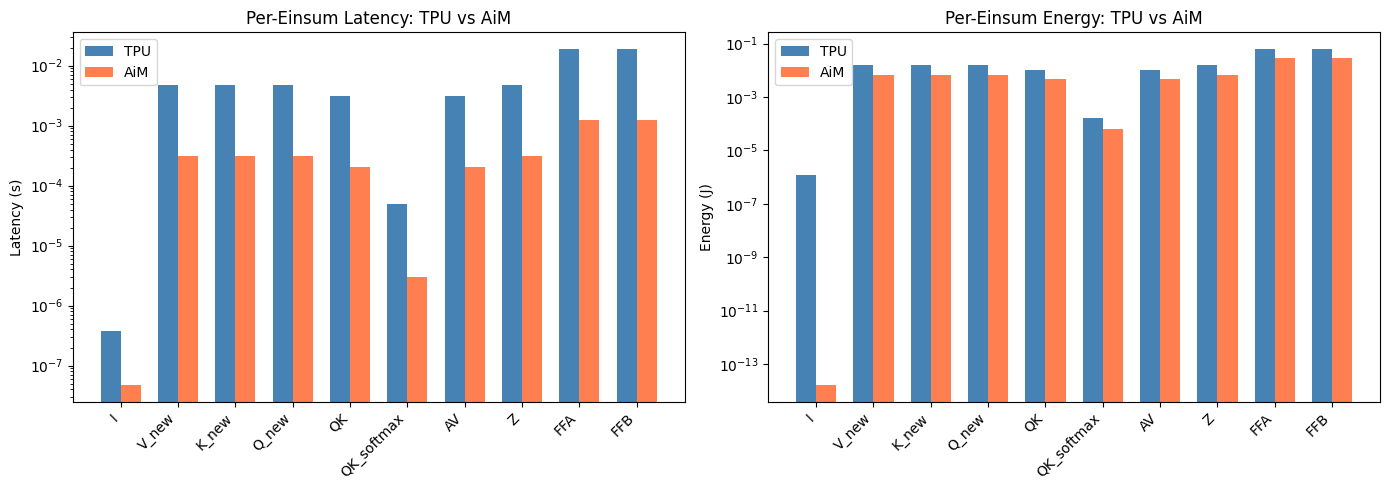

In [98]:
import matplotlib.pyplot as plt
import numpy as np

names = list(comparison.keys())
tpu_latencies = [comparison[n]["TPU"]["latency"] for n in names]
aim_latencies = [comparison[n]["AiM"]["latency"] for n in names]
tpu_energies = [comparison[n]["TPU"]["energy"] for n in names]
aim_energies = [comparison[n]["AiM"]["energy"] for n in names]

x = np.arange(len(names))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Latency comparison
ax1.bar(x - width/2, tpu_latencies, width, label="TPU", color="steelblue")
ax1.bar(x + width/2, aim_latencies, width, label="AiM", color="coral")
ax1.set_ylabel("Latency (s)")
ax1.set_title("Per-Einsum Latency: TPU vs AiM")
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=45, ha="right")
ax1.legend()
ax1.set_yscale("log")

# Energy comparison
ax2.bar(x - width/2, tpu_energies, width, label="TPU", color="steelblue")
ax2.bar(x + width/2, aim_energies, width, label="AiM", color="coral")
ax2.set_ylabel("Energy (J)")
ax2.set_title("Per-Einsum Energy: TPU vs AiM")
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=45, ha="right")
ax2.legend()
ax2.set_yscale("log")

plt.tight_layout()
plt.show()

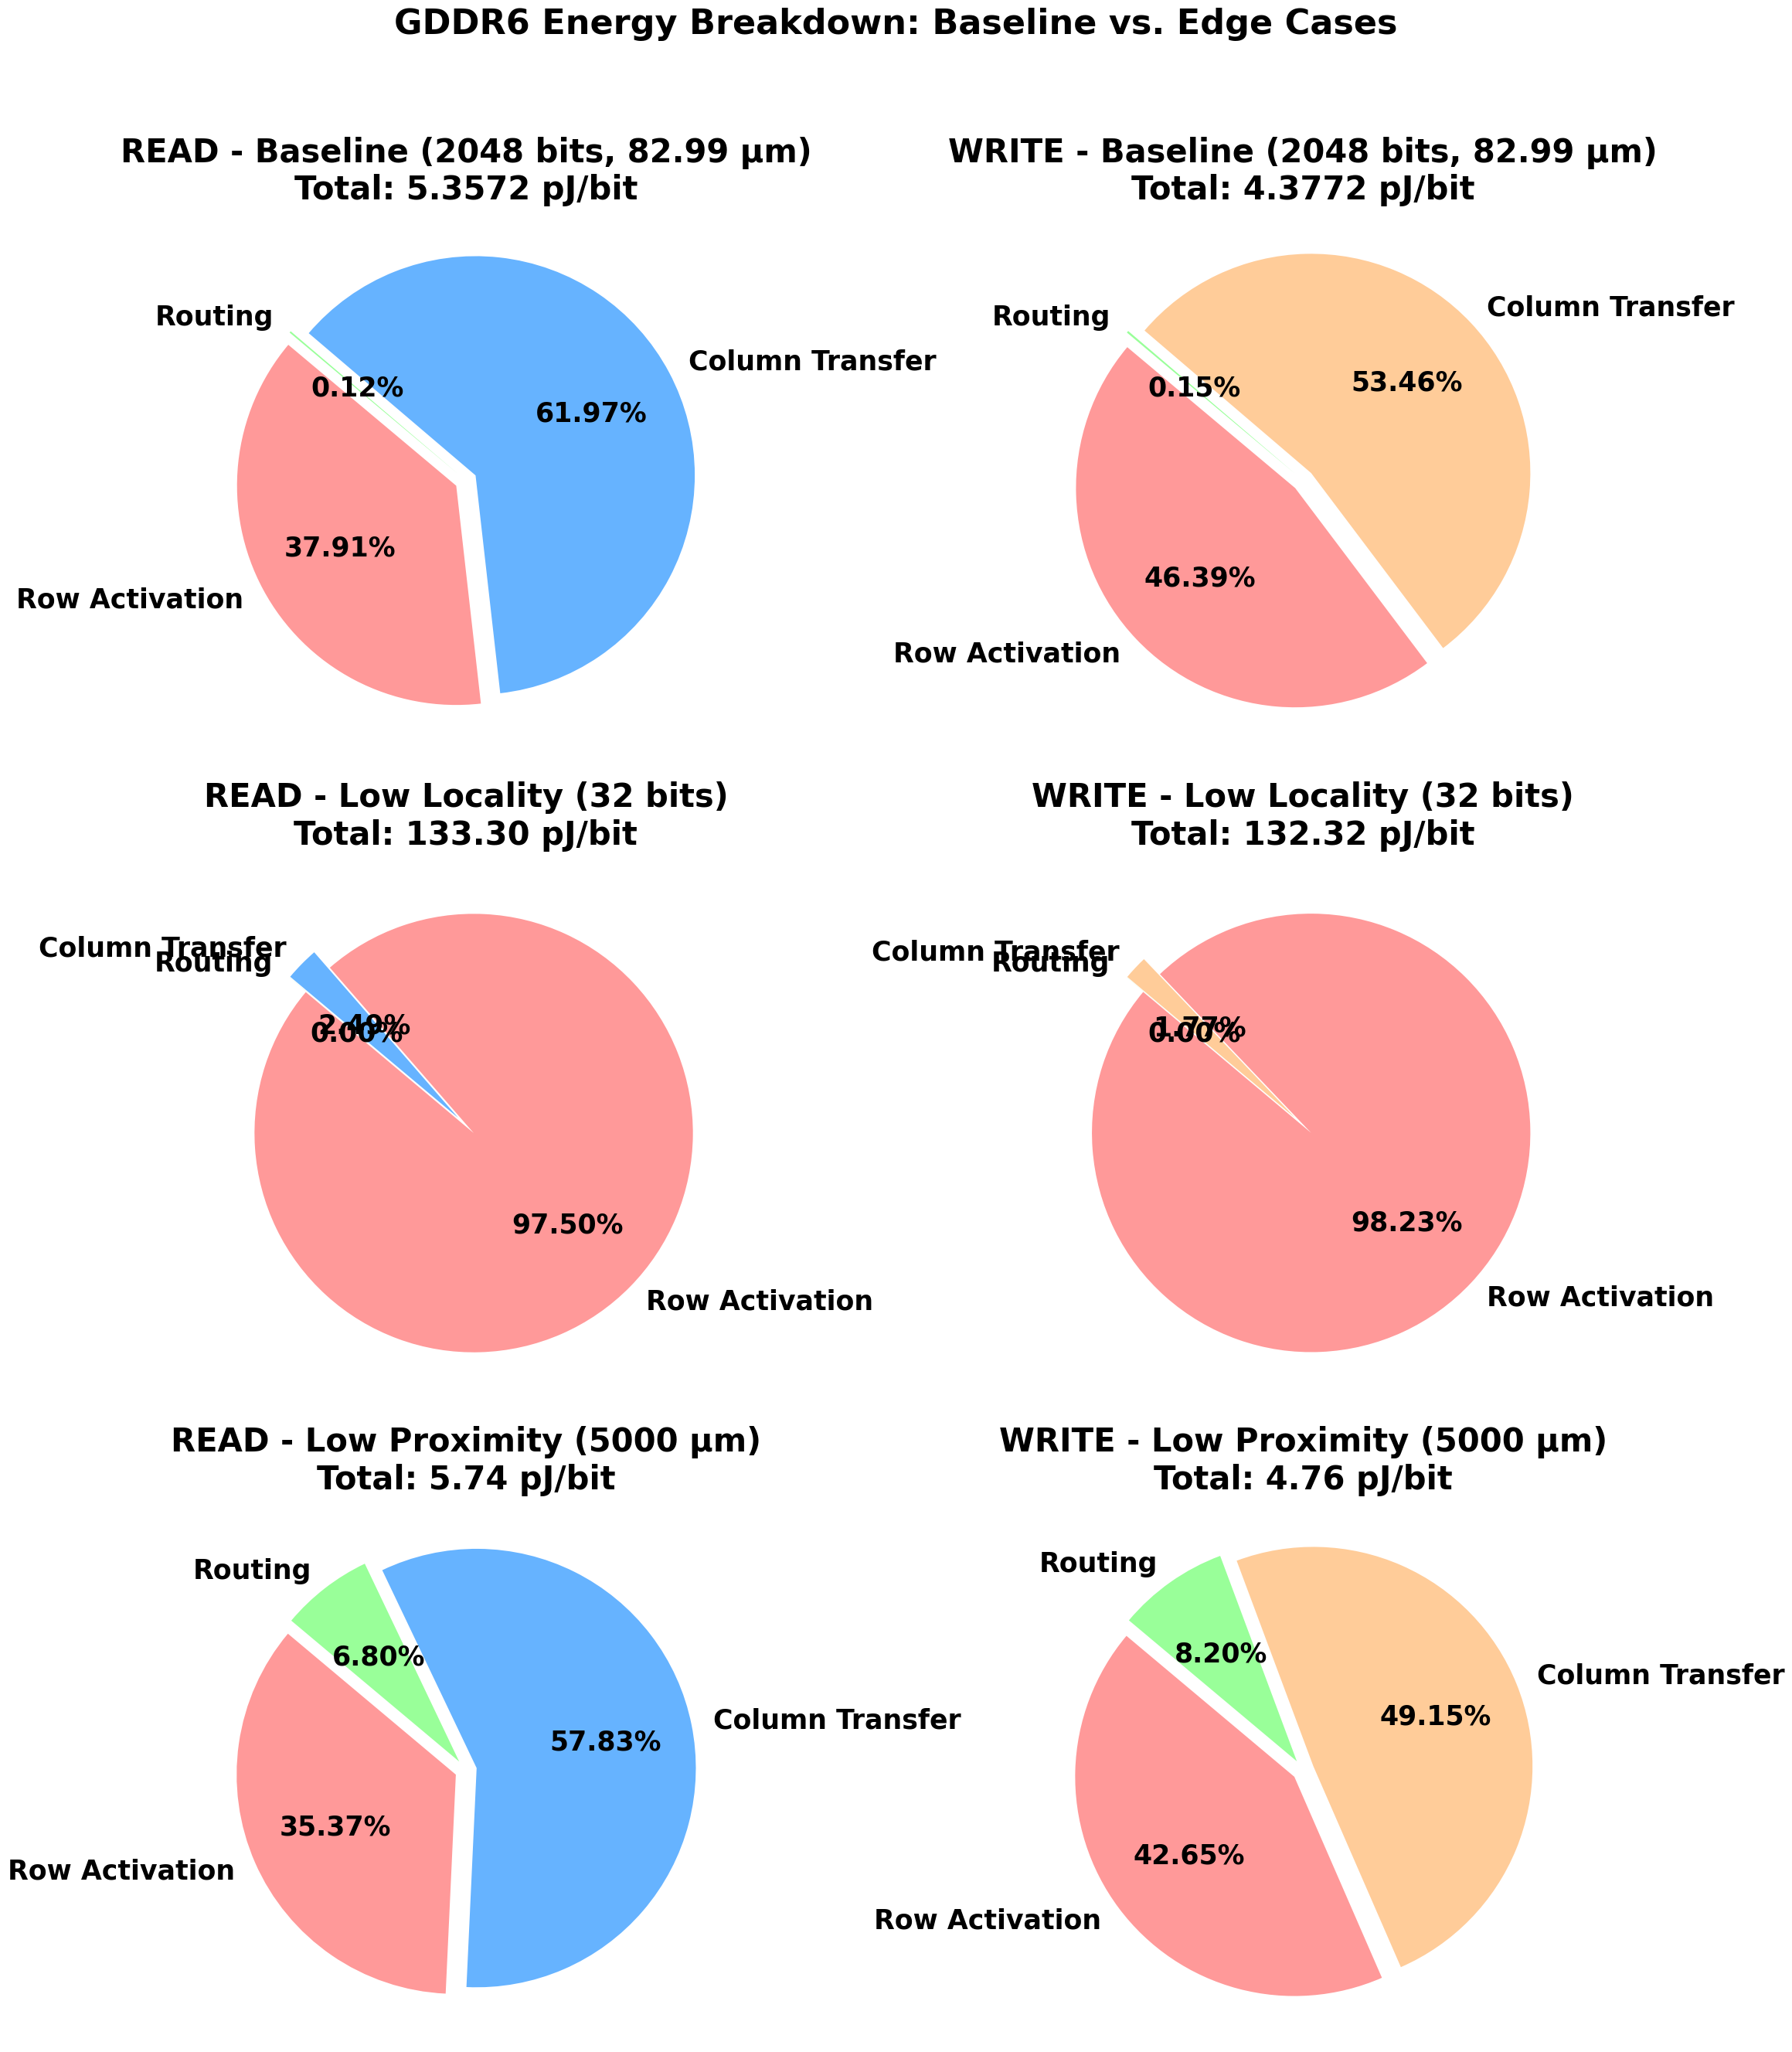

In [2]:
import matplotlib.pyplot as plt

# --- System Constants (Derived from your equations) ---
E_ACT_TOTAL = 4159.0        # pJ (Total Row Activation Energy)
E_COL_RD = 3.32             # pJ/bit (Column Read Energy)
E_COL_WR = 2.34             # pJ/bit (Column Write Energy)
ROUTING_COEFF = 0.000078125 # pJ/um (Calculated from: 0.25 * 0.2 fF/um * 1.25V^2)

PIE_LABEL_FONTSIZE = 25
PIE_TITLE_FONTSIZE = 30
PIE_SUPTITLE_FONTSIZE = 32

def calculate_energy(distance_um, locality_bits):
    """Calculates individual energy components given distance and locality."""
    e_route = distance_um * ROUTING_COEFF
    e_act_per_bit = E_ACT_TOTAL / locality_bits
    
    # Total dynamic energies
    total_rd = e_act_per_bit + E_COL_RD + e_route
    total_wr = e_act_per_bit + E_COL_WR + e_route
    
    return e_act_per_bit, e_route, total_rd, total_wr

def plot_six_pie_charts():
    """Plots a 3x2 grid of pie charts for Baseline, Low Locality, and Low Proximity."""
    
    # Define the three scenarios
    # Scenario 1: Baseline (Original values)
    base_dist, base_bits = 82.99, 2048
    # Scenario 2: Low Locality
    loc_dist, loc_bits = 82.99, 32
    # Scenario 3: Low Proximity (High Distance)
    prox_dist, prox_bits = 5000, 2048 
    
    # Calculate energies
    e_act_base, e_route_base, total_rd_base, total_wr_base = calculate_energy(base_dist, base_bits)
    e_act_loc, e_route_loc, total_rd_loc, total_wr_loc = calculate_energy(loc_dist, loc_bits)
    e_act_prox, e_route_prox, total_rd_prox, total_wr_prox = calculate_energy(prox_dist, prox_bits)
    
    fig, axs = plt.subplots(3, 2, figsize=(22, 28))
    labels = ['Row Activation', 'Column Transfer', 'Routing']
    colors_rd = ['#ff9999', '#66b3ff', '#99ff99']
    colors_wr = ['#ff9999', '#ffcc99', '#99ff99']
    explode = (0.05, 0.05, 0.05)
    pie_textprops = {'fontsize': PIE_LABEL_FONTSIZE, 'fontweight': 'bold'}

    # --- ROW 1: BASELINE (ORIGINAL) ---
    axs[0, 0].pie([e_act_base, E_COL_RD, e_route_base], labels=labels, autopct='%1.2f%%', 
                  startangle=140, colors=colors_rd, explode=explode, textprops=pie_textprops)
    axs[0, 0].set_title(f'READ - Baseline (2048 bits, 82.99 μm)\nTotal: {total_rd_base:.4f} pJ/bit', fontsize=PIE_TITLE_FONTSIZE, fontweight='bold')
    
    axs[0, 1].pie([e_act_base, E_COL_WR, e_route_base], labels=labels, autopct='%1.2f%%', 
                  startangle=140, colors=colors_wr, explode=explode, textprops=pie_textprops)
    axs[0, 1].set_title(f'WRITE - Baseline (2048 bits, 82.99 μm)\nTotal: {total_wr_base:.4f} pJ/bit', fontsize=PIE_TITLE_FONTSIZE, fontweight='bold')

    # --- ROW 2: LOW LOCALITY ---
    axs[1, 0].pie([e_act_loc, E_COL_RD, e_route_loc], labels=labels, autopct='%1.2f%%', 
                  startangle=140, colors=colors_rd, explode=explode, textprops=pie_textprops)
    axs[1, 0].set_title(f'READ - Low Locality ({loc_bits} bits)\nTotal: {total_rd_loc:.2f} pJ/bit', fontsize=PIE_TITLE_FONTSIZE, fontweight='bold')
    
    axs[1, 1].pie([e_act_loc, E_COL_WR, e_route_loc], labels=labels, autopct='%1.2f%%', 
                  startangle=140, colors=colors_wr, explode=explode, textprops=pie_textprops)
    axs[1, 1].set_title(f'WRITE - Low Locality ({loc_bits} bits)\nTotal: {total_wr_loc:.2f} pJ/bit', fontsize=PIE_TITLE_FONTSIZE, fontweight='bold')

    # --- ROW 3: LOW PROXIMITY ---
    axs[2, 0].pie([e_act_prox, E_COL_RD, e_route_prox], labels=labels, autopct='%1.2f%%', 
                  startangle=140, colors=colors_rd, explode=explode, textprops=pie_textprops)
    axs[2, 0].set_title(f'READ - Low Proximity ({prox_dist} μm)\nTotal: {total_rd_prox:.2f} pJ/bit', fontsize=PIE_TITLE_FONTSIZE, fontweight='bold')
    
    axs[2, 1].pie([e_act_prox, E_COL_WR, e_route_prox], labels=labels, autopct='%1.2f%%', 
                  startangle=140, colors=colors_wr, explode=explode, textprops=pie_textprops)
    axs[2, 1].set_title(f'WRITE - Low Proximity ({prox_dist} μm)\nTotal: {total_wr_prox:.2f} pJ/bit', fontsize=PIE_TITLE_FONTSIZE, fontweight='bold')

    fig.suptitle('GDDR6 Energy Breakdown: Baseline vs. Edge Cases', fontsize=PIE_SUPTITLE_FONTSIZE, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


plot_six_pie_charts()

arch             energy_j      latency_s        edp_j_s
----------------------------------------------------------
stack        1.254068e-01   4.680144e-03   5.869217e-04

stack arch render:


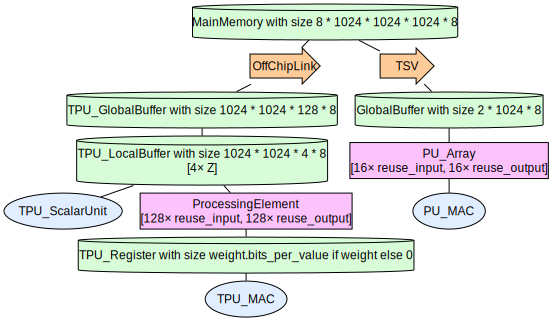

stack mapping render (EDP-best):


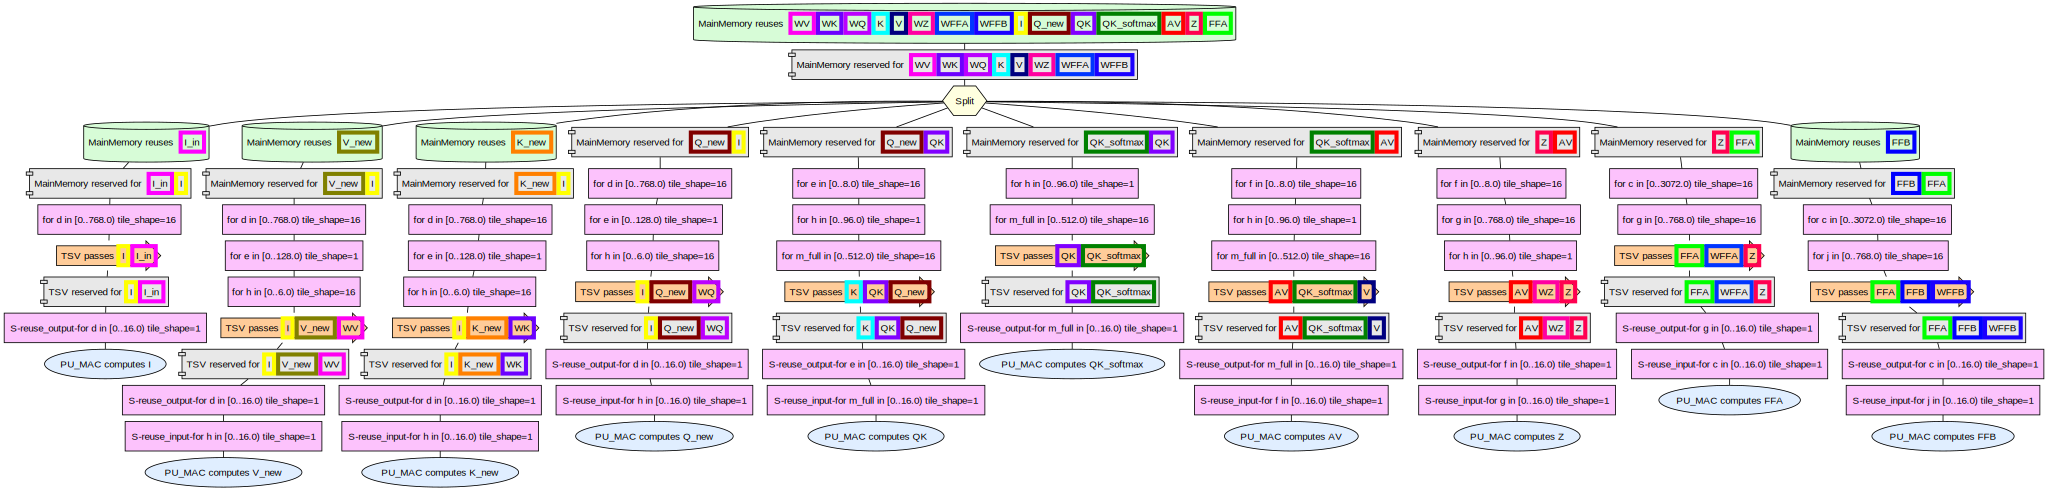

hybrid       9.283589e-02   4.182816e-03   3.883154e-04

hybrid arch render:


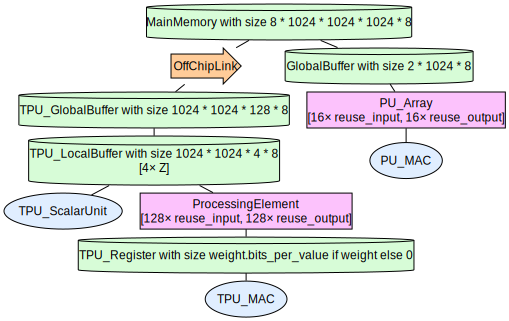

hybrid mapping render (EDP-best):


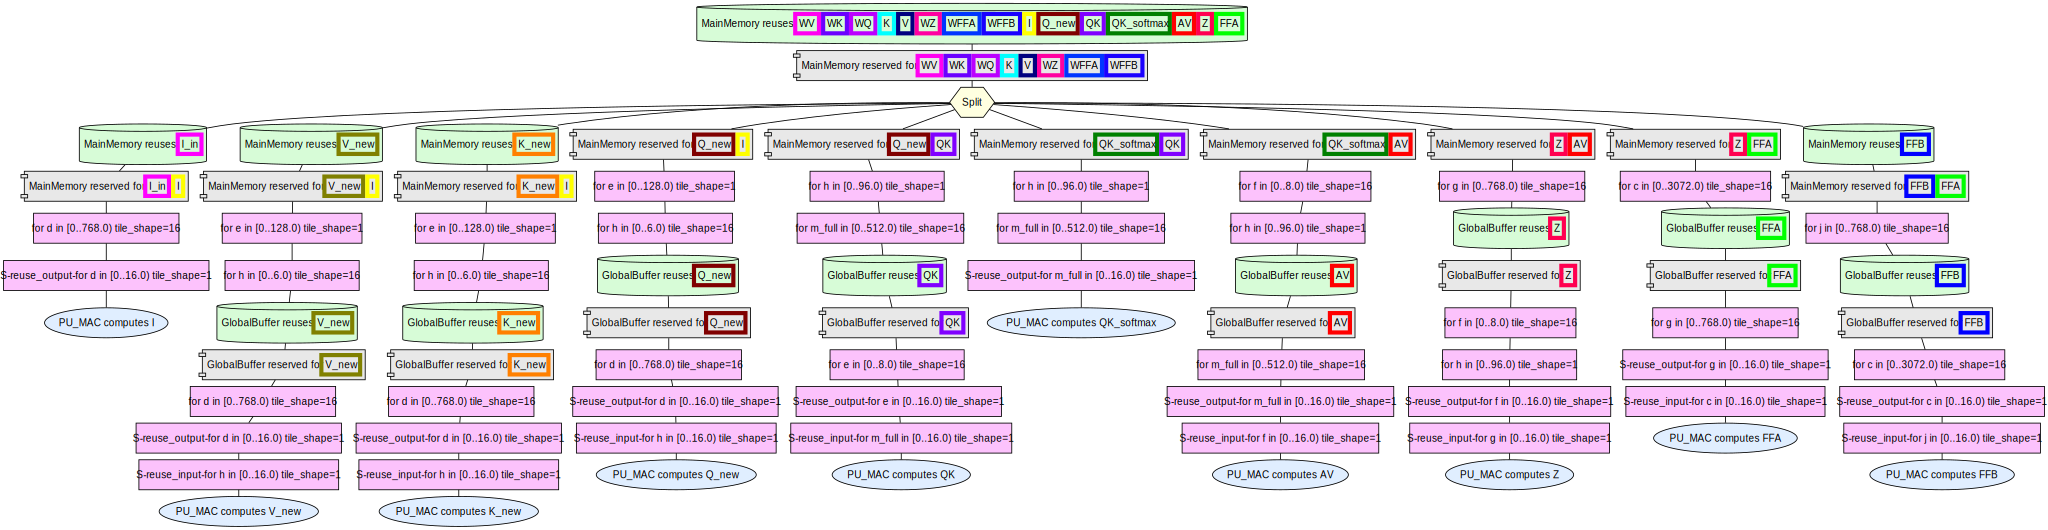

In [100]:
import contextlib, io
from IPython.display import display
import accelforge as af

WL = models_dir / "gpt3_6.7B_kv_cache.yaml"
arches = [
    ("hybrid", models_dir / "tpu_aim_hybrid.yaml"),
]

print(f"{'arch':<10} {'energy_j':>14} {'latency_s':>14} {'edp_j_s':>14}")
print('-' * 58)
for name, p in arches:
    s = af.Spec.from_yaml(p, WL, jinja_parse_data={'BATCH_SIZE': 1, 'N_TOKENS': 8192})
    s.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
    with contextlib.redirect_stdout(io.StringIO()):
        m = s.map_workload_to_arch(print_progress=False)

    energies = m.energy()
    latencies = m.latency()
    if isinstance(energies, list):
        i = min(range(len(energies)), key=lambda k: energies[k] * latencies[k])
        best = m[i]
        e = float(energies[i])
        l = float(latencies[i])
    else:
        best = m
        e = float(energies)
        l = float(latencies)

    print(f"{name:<10} {e:14.6e} {l:14.6e} {e*l:14.6e}")

    print(f"\n{name} arch render:")
    display(s.arch.render())

    print(f"{name} mapping render (EDP-best):")
    display(best.render())

    
    

